In [1]:
# https://www.kaggle.com/competitions/extreme-condensation-aicc-round-4

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score
from itertools import combinations
import math
from PIL import Image

In [2]:
num_classes = 10
seed = 2026

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [4]:
class CustomMNISTDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        img_rel_path = self.annotations.iloc[index, 0]
        img_path = os.path.join(self.root_dir, img_rel_path)
        image = Image.open(img_path).convert('L')
        label = int(self.annotations.iloc[index, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

dataset = CustomMNISTDataset(
    csv_file='/kaggle/input/extreme-condensation-aicc-round-4/train_labels.csv',
    root_dir='/kaggle/input/extreme-condensation-aicc-round-4/',
    transform=transform
)

loader = DataLoader(dataset, batch_size=128, shuffle=False)

In [5]:
pd.read_csv("/kaggle/input/extreme-condensation-aicc-round-4/train_labels.csv")['label'].value_counts()

label
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

In [6]:
class ConvNet(nn.Module):
    def __init__(self, num_classes: int = 10, width: int = 28):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(1, width, 3, padding=1),
            nn.InstanceNorm2d(width, affine=True),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),
            nn.Conv2d(width, width, 3, padding=1),
            nn.InstanceNorm2d(width, affine=True),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),
        )
        self.fc = nn.Linear(width * 7 * 7, num_classes)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                nn.init.zeros_(m.bias)
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0.0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.f(x)
        x = x.flatten(1)
        return self.fc(x)

In [7]:
model = ConvNet(num_classes=10, width = 32)
steps = 50  # T: Number of gradient descent steps
lr = 0.01
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

In [8]:
digits = range(10)

d2images = dict([(d, []) for d in digits])

for X, y in tqdm(loader, desc='Loader'):
    for d in digits:
        portion = X[torch.where(y == d)[0]]
        if len(portion.shape) == 3:
            portion = portion.unsqueeze(0)
        d2images[d].append(portion)

for d in digits:
    d2images[d] = torch.concat(d2images[d], dim=0)

Loader:   0%|          | 0/469 [00:00<?, ?it/s]

In [9]:
def fit(model, optimizer, criterion, image, label, steps=steps):
    model.train()
    device = next(model.parameters()).device
    image = image.to(device)
    label = label.to(device)
    for epoch in range(steps):
        output = model(image)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def eval(model, criterion, loader, limit=1):
    model.eval()
    device = next(model.parameters()).device
    all_y, all_preds = [], []
    total_loss, i = 0, 0
    for X, y in loader:
        if i >= limit:
            break
        X, y = X.to(device), y.to(device)
        with torch.no_grad():
            output = model(X)
            loss = criterion(output, y)
            probs = torch.softmax(output, dim=1)
            preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() 
        i += 1
        all_y.extend(y.flatten().cpu().tolist())
        all_preds.extend(preds.flatten().cpu().tolist())
        
    return total_loss / i, accuracy_score(all_y, all_preds)

In [10]:
def get_mean_image_label(digits):
    image = []
    label = torch.zeros(10)
    for d in digits:
        image.append(d2images[d])
        label[d] += d2images[d].shape[0]
    image = torch.cat(image, dim=0)
    image = image.mean(dim=0)
    label /= label.sum()
    return image.unsqueeze(0), label.unsqueeze(0)

In [11]:
results = []
images, labels = [], []

for k in tqdm(range(1, 10+1), desc='Choosing'):
    for digits in tqdm(combinations(range(10), k), total=math.comb(10, k), desc='Combination', leave=False):
        model = ConvNet(num_classes=10, width = 32)
        steps = 50
        lr = 0.01
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        image, label = get_mean_image_label(digits)
        images.append(image)
        labels.append(label)
        
        fit(model, optimizer, criterion, image, label)
        loss, acc = eval(model, criterion, loader)
        results.append((digits, loss, acc))

Choosing:   0%|          | 0/10 [00:00<?, ?it/s]

Combination:   0%|          | 0/10 [00:00<?, ?it/s]

Combination:   0%|          | 0/45 [00:00<?, ?it/s]

Combination:   0%|          | 0/120 [00:00<?, ?it/s]

Combination:   0%|          | 0/210 [00:00<?, ?it/s]

...

Combination:   0%|          | 0/210 [00:00<?, ?it/s]

Combination:   0%|          | 0/120 [00:00<?, ?it/s]

Combination:   0%|          | 0/45 [00:00<?, ?it/s]

Combination:   0%|          | 0/10 [00:00<?, ?it/s]

Combination:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
res_df = pd.DataFrame(results, columns=['digits', 'loss', 'acc'])
res_df = res_df.sort_values('acc', ascending=False)
res_df

,digits,loss,acc
703,"(0, 1, 5, 6, 7, 9)",11.999478,0.273438
394,"(0, 1, 2, 4, 8)",13.568253,0.265625
564,"(1, 3, 6, 8, 9)",15.062152,0.257812
434,"(0, 1, 5, 7, 8)",17.443583,0.250000
10,"(0, 1)",26.840599,0.250000
...,...,...,...
190,"(0, 1, 4, 7)",15.930282,0.015625
414,"(0, 1, 3, 5, 9)",14.934334,0.015625
258,"(0, 7, 8, 9)",18.049980,0.007812
193,"(0, 1, 5, 6)",20.271984,0.007812


In [13]:
chosen_image = images[res_df.index[0]]
chosen_label = labels[res_df.index[0]]

chosen_image.shape, chosen_label.shape

(torch.Size([1, 1, 28, 28]), torch.Size([1, 10]))

tensor([[0.1635, 0.1862, 0.0000, 0.0000, 0.0000, 0.1497, 0.1634, 0.1730, 0.0000,
         0.1643]])


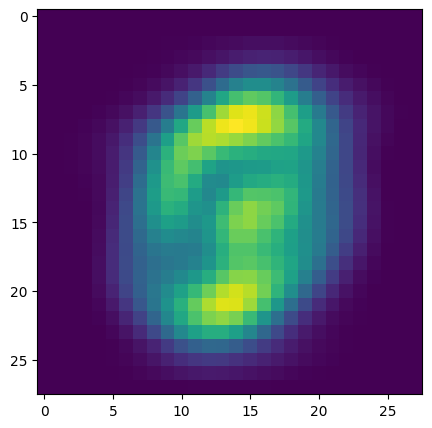

In [14]:
plt.figure(figsize=(5, 5))

plt.imshow(chosen_image.squeeze())
print(chosen_label)
plt.show()

In [15]:
flat_pixels = chosen_image.flatten().cpu().numpy()

soft_labels = chosen_label.flatten().cpu().numpy()

pixel_data = {f"p{i}": [val] for i, val in enumerate(flat_pixels)}
label_data = {f"l{i}": [val] for i, val in enumerate(soft_labels)}

df_submission = pd.DataFrame({
    "id": [0],
    **pixel_data,
    **label_data
})

output_filename = "submission.csv"
df_submission.to_csv(output_filename, index=False)

print(f"Success! Baseline saved to {output_filename}")
print(f"Submission Dimensions: {df_submission.shape}")
print(f"Label Shape: {len(soft_labels.tolist())}")

Success! Baseline saved to submission.csv
Submission Dimensions: (1, 795)
Label Shape: 10
